## SWE - mpi4py - SOLUTION

MPI is a distributed computing model: `mpirun` starts many copies of your
program as independent processes that share no memory and communicate by
explicit messages, instead of the single accelerated process we saw with
JAX, PyOMP, nanobind, and CppJIT. mpi4py brings that model to Python.

Here that means splitting the channel into contiguous **slabs**, one per
process, each holding its slab plus one **ghost cell** per side; neighbours
swap edge cells before every step (the **halo exchange**). The kernel is
untouched: each rank advances its slab with `swe_core.step_numpy`. This
notebook is about the decomposition and what the communication costs.

**SOLUTION**

### Table of Contents

1. [Imports and the launch pattern](#sec1)
2. [The decomposition probe](#sec2)
3. [The halo exchange](#sec3)
4. [Acceptance and timing](#sec4)
5. [Rank scaling](#sec5)
6. [Overlapping communication and computation](#sec6)

### <a id="sec1"></a>1. Imports and the launch pattern

An MPI program is `size` identical copies of one script started together;
each copy asks for its **rank** to find its role. The notebook kernel is
not one of those copies, so every program below is written out with
`%%writefile` and launched with `run_mpi`.

---

**Quick Docs**

- `MPI.COMM_WORLD`: the communicator spanning every rank of the launch;
  `Get_rank()` / `Get_size()` return this copy's id and the total count.
- `run_mpi(ranks, script, *args)`: launch under the detected MPI
  implementation. `MPI.get_vendor()` selects the matching launcher, so the
  same cell works against Open MPI and MPICH.
- `mpi_result(...)`: the same launch, returning the `RESULT` record rank 0
  prints. Timing inside the script keeps launcher and `MPI_Init` startup
  out of the numbers.

In [1]:
import json
import os
import shutil
import subprocess
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import mpi4py
import psutil

import swe_core

# Install Open MPI and mpi4py if running in Google Colab.
colab_marker = Path("/tmp/accelerated-computing-hub-mpi4py-installed")
if os.getenv("COLAB_RELEASE_TAG") and not colab_marker.exists():
    print("Installing Open MPI and mpi4py.")
    subprocess.run(["apt-get", "-qq", "update"], check=True)
    subprocess.run(
        ["apt-get", "-qq", "install", "-y", "openmpi-bin", "libopenmpi-dev"],
        check=True,
        stdout=subprocess.DEVNULL,
    )
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "mpi4py"],
        check=True,
        stdout=subprocess.DEVNULL,
    )
    colab_marker.touch()
    print("Open MPI and mpi4py installed.")

# Open MPI protects against accidental root launches. Colab and the tutorial
# container are isolated environments where explicitly allowing this is safe.
os.environ.setdefault("OMPI_ALLOW_RUN_AS_ROOT", "1")
os.environ.setdefault("OMPI_ALLOW_RUN_AS_ROOT_CONFIRM", "1")

# Match the launcher to the MPI library against which mpi4py was built.
vendor_result = subprocess.run(
    [
        sys.executable,
        "-c",
        "from mpi4py import MPI; print(MPI.get_vendor()[0])",
    ],
    check=True,
    capture_output=True,
    text=True,
)
MPI_VENDOR = vendor_result.stdout.strip()

if MPI_VENDOR == "MPICH":
    mpi_launcher = (
        shutil.which("mpirun.mpich")
        or shutil.which("mpiexec.mpich")
        or shutil.which("mpiexec")
    )
    if mpi_launcher is None:
        raise RuntimeError("No MPICH launcher was found")
    # Do not delegate this nested launch back to Slurm on CSCS.
    MPI_LAUNCHER = [mpi_launcher, "-launcher", "fork"]
elif MPI_VENDOR == "Open MPI":
    mpi_launcher = shutil.which("mpirun.openmpi") or shutil.which("mpirun")
    if mpi_launcher is None:
        raise RuntimeError("No Open MPI launcher was found")
    MPI_LAUNCHER = [mpi_launcher, "--oversubscribe"]
else:
    mpi_launcher = shutil.which("mpiexec")
    if mpi_launcher is None:
        raise RuntimeError(f"No launcher was found for {MPI_VENDOR}")
    MPI_LAUNCHER = [mpi_launcher]


def run_program(command):
    '''Run a child program, display its output, and fail on errors.'''
    result = subprocess.run(
        command,
        capture_output=True,
        text=True,
        timeout=180,
    )
    print(result.stdout, end="")
    if result.stderr:
        print(result.stderr, end="", file=sys.stderr)
    result.check_returncode()


def run_mpi(rank_count, script):
    '''Run a Python script under the selected MPI implementation.'''
    command = [
        *MPI_LAUNCHER,
        "-n",
        str(rank_count),
        sys.executable,
        "-u",
        script,
    ]
    run_program(command)


def run_python(script):
    '''Run a serial Python reference with the notebook's interpreter.'''
    run_program([sys.executable, "-u", script])


def mpi_result(rank_count, script, *args):
    '''Launch a script and return the RESULT record rank 0 prints.'''
    result = subprocess.run(
        [*MPI_LAUNCHER, "-n", str(rank_count),
         sys.executable, "-u", script, *map(str, args)],
        capture_output=True,
        text=True,
        timeout=900,
    )
    if result.stderr:
        print(result.stderr, end="", file=sys.stderr)
    result.check_returncode()
    line = next((l for l in result.stdout.splitlines()
                 if l.startswith("RESULT ")), None)
    assert line, result.stdout
    return json.loads(line[len("RESULT "):])


# Use a teaching-scale rank count; large shared nodes may expose hundreds of cores.
N_RANKS = min(32, psutil.cpu_count(logical=False) or os.cpu_count())

# Shared problem identity, for reporting. The solver script restates the
# full configuration: each MPI process is its own interpreter.
N       = 16384
N_STEPS = 1000

### <a id="sec2"></a>2. The decomposition probe

`N` interior cells split into `size` contiguous slabs, remainder cells
going to the lowest ranks. Each rank stores `local_N + 2` cells: its slab
plus one ghost per side. Five ranks does not divide `N = 16384` evenly, so
the probe shows the uneven split.

---

**Quick Docs**

- `divmod(N, size)`: base slab length and remainder; the first
  `remainder` ranks take one extra cell.

In [2]:
%%writefile swe_mpi_decomp.py
"""Slab decomposition probe: every rank reports the cells it owns."""
from mpi4py import MPI

N = 16384

comm = MPI.COMM_WORLD
rank = comm.Get_rank()
size = comm.Get_size()

# Split N interior cells into `size` contiguous slabs
# ranks below N % size take one extra cell.
local_N = N // size + (1 if rank < N % size else 0)
offset  = rank * (N // size) + min(rank, N % size)

rows = comm.gather((rank, offset, local_N), root=0)
if rank == 0:
    for r, o, n in rows:
        print(f"rank {r}/{size}: interior cells [{o:>6}, {o + n:>6})  local_N = {n:,}")
    assert sum(n for _, _, n in rows) == N, "cells lost or duplicated"

Overwriting swe_mpi_decomp.py


In [3]:
run_mpi(5, "swe_mpi_decomp.py")

rank 0/5: interior cells [     0,   3277)  local_N = 3,277
rank 1/5: interior cells [  3277,   6554)  local_N = 3,277
rank 2/5: interior cells [  6554,   9831)  local_N = 3,277
rank 3/5: interior cells [  9831,  13108)  local_N = 3,277
rank 4/5: interior cells [ 13108,  16384)  local_N = 3,276


### <a id="sec3"></a>3. The halo exchange

Each update reads a cell's two neighbours. Interior cells of a slab find
both locally; the first and last cell each need one cell owned by the
neighbouring rank, delivered into the ghosts before every step:

- **Exchange**: `Sendrecv` copies each neighbour's edge cell into the
  ghost, in both directions.
- **Walls**: rank 0 mirrors its left ghost, the last rank its right
  ghost.
- **Step**: `swe_core.step_numpy` on the local array, unchanged.

Every interior cell then sees the same neighbour values as the serial
solve, so the gate expects `max_diff` exactly zero.

---

**Quick Docs**

- `comm.Sendrecv(sendbuf, dest=.., sendtag=.., recvbuf=.., source=..,
  recvtag=..)`: one paired send and receive. The runtime schedules the
  pair, so neighbour chains cannot deadlock.
- `MPI.PROC_NULL`: the no-op peer. A transfer with it completes
  immediately; the wall ranks use it as their missing neighbour.
- Uppercase methods (`Sendrecv`, `Isend`, `Gatherv`) move NumPy buffers
  zero-copy; any contiguous slice like `h[-2:-1]` is a valid message
  buffer.
- `comm.Gatherv(sendbuf, (recvbuf, counts), root=0)`: concatenate
  unequal-length slabs on one rank. The acceptance gate uses it.

In [4]:
%%writefile swe_mpi_solver.py
"""Distributed 1D SWE solver: slab decomposition + halo exchange.

Rank 0 prints one result: max-over-ranks wall times and the
max_diff.
"""
import os
os.environ.setdefault("OMP_NUM_THREADS", "1")   # pure MPI: one thread per rank

import json, sys
import numpy as np
from mpi4py import MPI

import swe_core

# Shared problem parameters; sweep runs pass N and N_STEPS on the CLI.
_args   = [a for a in sys.argv[1:] if not a.startswith('-')]
N       = int(_args[0]) if _args else 16384
L       = 10.0
H0      = 1.0
AMP     = 0.1
SIG     = 0.5
CFL     = 0.4
G       = 9.81
N_STEPS = int(_args[1]) if len(_args) > 1 else 1000
dx      = L / N
DT      = swe_core.fixed_dt(H0 + AMP, dx, cfl=CFL, g=G)

comm  = MPI.COMM_WORLD
rank  = comm.Get_rank()
size  = comm.Get_size()
left  = rank - 1 if rank > 0        else MPI.PROC_NULL
right = rank + 1 if rank < size - 1 else MPI.PROC_NULL

# Slab partition (Sec. 2).
local_N = N // size + (1 if rank < N % size else 0)
offset  = rank * (N // size) + min(rank, N % size)


def halo_exchange(h, hu):
    """Fill the ghost cells from the neighbours' edge interior cells."""
    # Shift east: last interior cell -> right neighbour's left ghost.
    comm.Sendrecv(h[-2:-1],  dest=right, sendtag=0, recvbuf=h[:1],  source=left, recvtag=0)
    comm.Sendrecv(hu[-2:-1], dest=right, sendtag=1, recvbuf=hu[:1], source=left, recvtag=1)
    # Shift west: first interior cell -> left neighbour's right ghost.
    comm.Sendrecv(h[1:2],  dest=left, sendtag=2, recvbuf=h[-1:],  source=right, recvtag=2)
    comm.Sendrecv(hu[1:2], dest=left, sendtag=3, recvbuf=hu[-1:], source=right, recvtag=3)


def exchange_and_bc(h, hu):
    """Ghost cells from the neighbours. Physical walls on the end ranks."""
    halo_exchange(h, hu)
    if rank == 0:
        h[0]  =  h[1];   hu[0]  = -hu[1]
    if rank == size - 1:
        h[-1] =  h[-2];  hu[-1] = -hu[-2]


def solve_local():
    """Slab IC, then N_STEPS of exchange / BC / step on the local slab."""
    h_g, hu_g = swe_core.bump_ic(N, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h  = h_g [offset : offset + local_N + 2].copy()
    hu = hu_g[offset : offset + local_N + 2].copy()
    for _ in range(N_STEPS):
        exchange_and_bc(h, hu)
        h, hu = swe_core.step_numpy(h, hu, dx, DT, g=G)
    return h, hu


def timed(fn):
    """Max-over-ranks wall time of one fn() call: the slowest rank sets it."""
    comm.Barrier()
    t0  = MPI.Wtime()
    out = fn()
    return comm.allreduce(MPI.Wtime() - t0, op=MPI.MAX), out


def benchmark(solve):
    """Cold pass + one warm-up, then 5 timed repeats; gate and report."""
    cold_s, _ = timed(solve)          # first pass: first-touch + numpy warm-up
    timed(solve)
    ts, h = [], None
    for _ in range(5):
        dt_s, (h, _hu) = timed(solve)
        ts.append(dt_s)

    # Acceptance: gather the interior slabs to rank 0, compare to the reference.
    counts = [N // size + (1 if r < N % size else 0) for r in range(size)]
    h_all  = np.empty(N) if rank == 0 else None
    comm.Gatherv(h[1:-1], (h_all, counts) if rank == 0 else None, root=0)
    if rank == 0:
        h_ref, _ = swe_core.solve_numpy(N, N_STEPS)
        print("RESULT " + json.dumps({
            "ranks": size, "cold_s": cold_s,
            "median_s": float(np.median(ts)), "min_s": float(np.min(ts)),
            "max_s": float(np.max(ts)), "repeats": len(ts),
            "max_diff": swe_core.max_diff(h_ref[1:-1], h_all)}))


def halo_cost(reps=20_000, step_reps=500):
    """Per-step cost of the exchange alone vs the local compute alone."""
    h_g, hu_g = swe_core.bump_ic(N, L=L, h0=H0, amplitude=AMP, sigma=SIG)
    h  = h_g [offset : offset + local_N + 2].copy()
    hu = hu_g[offset : offset + local_N + 2].copy()

    def exchanges():
        for _ in range(reps):
            exchange_and_bc(h, hu)

    def steps():
        for _ in range(step_reps):
            swe_core.step_numpy(h, hu, dx, DT, g=G)

    t_x = min(timed(exchanges)[0] for _ in range(3)) / reps       # min of 3: the floor
    t_c = min(timed(steps)[0] for _ in range(3)) / step_reps
    if rank == 0:
        print(f"halo exchange: {t_x * 1e6:6.2f} us/step  (4 messages, 8 B each)")
        print(f"local step   : {t_c * 1e6:6.2f} us/step  (local_N = {local_N:,})")


if __name__ == "__main__":
    halo_cost() if "--halo-cost" in sys.argv else benchmark(solve_local)

Overwriting swe_mpi_solver.py


### <a id="sec4"></a>4. Acceptance and timing

Timing lives inside the script: `Barrier`, then `MPI.Wtime` around a full
solve, then a max over ranks (the slowest rank sets the wall clock).
Rank 0 gathers the slabs with `Gatherv`, computes `max_diff` against the
float64 reference, and prints one `RESULT` line for the notebook to
record.

In [5]:
res = mpi_result(N_RANKS, "swe_mpi_solver.py")

warm = {'label': '13_mpi4py', 'median_s': res['median_s'],
        'min_s': res['min_s'], 'max_s': res['max_s'], 'repeats': res['repeats']}
swe_core.report_and_verify(warm, res['max_diff'], tol=1e-12,
                           cold_s=res['cold_s'], n=N, steps=N_STEPS,
                           cold_note='first solve pass; excl. mpirun + MPI_Init')

swe_core.save_timing(
    warm, grid_str=f'N={N}', tool='mpi4py', hardware='cpu',
    dtype='float64', steps=N_STEPS,
    cold_s=res['cold_s'], max_diff_vs_numpy=res['max_diff'],
    ranks=res['ranks'], mpi4py_version=mpi4py.__version__,
)

[13_mpi4py] N=16384 steps=1000 | cold    45.6 ms (first solve pass; excl. mpirun + MPI_Init) | warm    42.2 ms | max_diff 0.00e+00 < tol 1e-12 | PASS


### <a id="sec5"></a>5. Rank scaling

The same script scales with `mpirun -n`. The sweep
runs powers of two up to the physical-core count.

**Predict before run:** each rank steps `N / ranks` cells but pays the
same four messages per step however small the slab gets. Sketch
throughput against rank count.

The halo payload is 8 bytes per message, so the exchange cost is
latency. Measure it against the local step alone, at 2 ranks:

In [6]:
run_program([*MPI_LAUNCHER, "-n", "2",
             sys.executable, "-u", "swe_mpi_solver.py", "--halo-cost"])

halo exchange:   2.93 us/step  (4 messages, 8 B each)
local step   : 322.98 us/step  (local_N = 8,192)


  ranks = 1:   161.0 ms     101.8 Mcells/s   max_diff 0.0e+00


  ranks = 2:    88.1 ms     185.9 Mcells/s   max_diff 0.0e+00


  ranks = 4:    54.3 ms     301.7 Mcells/s   max_diff 0.0e+00


  ranks = 8:    40.9 ms     400.8 Mcells/s   max_diff 0.0e+00


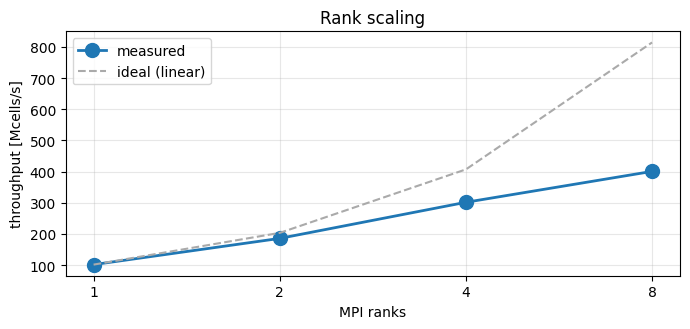

In [7]:
RANK_COUNTS = [1]
while RANK_COUNTS[-1] * 2 <= N_RANKS:
    RANK_COUNTS.append(RANK_COUNTS[-1] * 2)

sweep = []
for n_ranks in RANK_COUNTS:
    r = mpi_result(n_ranks, "swe_mpi_solver.py")
    assert r['max_diff'] < 1e-12, f'gate failed at {n_ranks} ranks'
    rate = N * N_STEPS / r['median_s'] / 1e6
    sweep.append((n_ranks, r['median_s'], rate))
    print(f'  ranks = {n_ranks}:  {r["median_s"]*1000:6.1f} ms   '
          f'{rate:7.1f} Mcells/s   max_diff {r["max_diff"]:.1e}')

ranks = [s[0] for s in sweep]
rates = [s[2] for s in sweep]

fig, ax = plt.subplots(figsize=(7, 3.4))
ax.plot(ranks, rates, 'o-', linewidth=2, markersize=10, label='measured')
ax.plot(ranks, [rates[0] * n for n in ranks], '--', color='#aaa', label='ideal (linear)')
ax.set_xscale('log', base=2)
ax.set_xticks(ranks); ax.set_xticklabels([str(n) for n in ranks])
ax.set_xlabel('MPI ranks'); ax.set_ylabel('throughput [Mcells/s]')
ax.set_title('Rank scaling')
ax.legend(); ax.grid(alpha=0.3); plt.tight_layout(); plt.show()

**Takeaways:**

- Throughput bends away from ideal well before the core count. - The exchange
  is cheap next to the step itself. The floor is the NumPy kernel's fixed
  per-step cost, paid by every rank on an ever-smaller slab.
- Halving the slab halves the compute but not the fixed cost: the
  surface-to-volume effect.

In [8]:
# Rates across the shared size range, for the synthesis notebook (14).
from pathlib import Path

sweep = []
for n_, steps_ in swe_core.SWEEP_SIZES:
    r = mpi_result(N_RANKS, "swe_mpi_solver.py", n_, steps_)
    assert r['max_diff'] < 1e-12, (n_, r)
    sweep.append({'n': n_, 'steps': steps_, 'median_s': r['median_s']})
    print(f"N={n_:>10,} steps={steps_:>5}: {n_ * steps_ / r['median_s'] / 1e6:7.0f} Mcells/s")

records = swe_core.load_timings()
row = next(rr for rr in records if rr.get('stage') == '13_mpi4py')
row['sweep'] = sweep
Path(swe_core.TIMINGS_PATH).write_text(json.dumps(records, indent=2))

N=    16,384 steps= 1000:     406 Mcells/s


N=   262,144 steps=  500:     777 Mcells/s


N= 1,048,576 steps=  200:     318 Mcells/s


N= 4,194,304 steps=  100:     102 Mcells/s


N=16,777,216 steps=   50:      63 Mcells/s


9314

### <a id="sec6"></a>6. Overlapping communication and computation

The blocking loop serialises exchange and compute, yet only the first
and last interior cell of a slab read the ghosts. A non-blocking
pattern like:

- post `Irecv`/`Isend`
- update the interior
- `Waitall`
- update the two edge cells

steps every other cell while the messages are being passed.

Sec. 5 measured the exchange cost. Predict: how much can hiding it save,
and what does splitting one `step_numpy` call into three cost?

---

**Quick Docs**

- `comm.Irecv(buf, source=..)` / `comm.Isend(buf, dest=..)`: post
  nonblocking transfers, each returning a `Request`.
- `MPI.Request.Waitall(reqs)`: block until every request completes.

In [9]:
%%writefile swe_mpi_overlap.py
# EXTRA CREDIT: hide the halo exchange behind the interior computation.
"""Non-blocking halo exchange overlapped with the interior update.

Only the first and last interior cell of a slab read the ghosts. Post the
exchange, step every other cell while the messages fly, wait, then step
those two. Reuses the decomposition and harness of swe_mpi_solver.
"""
import numpy as np
from mpi4py import MPI

import swe_core
import swe_mpi_solver as s


def step_overlap(h, hu):
    """One step: Isend/Irecv, interior update, Waitall, edge update."""
    reqs = [
        s.comm.Irecv(h[:1],     source=s.left,  tag=0),
        s.comm.Irecv(hu[:1],    source=s.left,  tag=1),
        s.comm.Irecv(h[-1:],    source=s.right, tag=2),
        s.comm.Irecv(hu[-1:],   source=s.right, tag=3),
        s.comm.Isend(h[-2:-1],  dest=s.right,   tag=0),
        s.comm.Isend(hu[-2:-1], dest=s.right,   tag=1),
        s.comm.Isend(h[1:2],    dest=s.left,    tag=2),
        s.comm.Isend(hu[1:2],   dest=s.left,    tag=3),
    ]
    # Interior cells 2 .. local_N-1 read no ghosts: step them during the exchange.
    h_mid, hu_mid = swe_core.step_numpy(h[1:-1], hu[1:-1], s.dx, s.DT, g=s.G)
    MPI.Request.Waitall(reqs)
    # Ghosts are now valid: physical walls first, then the two edge cells.
    if s.rank == 0:
        h[0]  =  h[1];   hu[0]  = -hu[1]
    if s.rank == s.size - 1:
        h[-1] =  h[-2];  hu[-1] = -hu[-2]
    h_lo, hu_lo = swe_core.step_numpy(h[:3],  hu[:3],  s.dx, s.DT, g=s.G)
    h_hi, hu_hi = swe_core.step_numpy(h[-3:], hu[-3:], s.dx, s.DT, g=s.G)

    h_new, hu_new = np.empty_like(h), np.empty_like(hu)
    h_new[0],    hu_new[0]    = h[0],        hu[0]
    h_new[-1],   hu_new[-1]   = h[-1],       hu[-1]
    h_new[1],    hu_new[1]    = h_lo[1],     hu_lo[1]
    h_new[-2],   hu_new[-2]   = h_hi[1],     hu_hi[1]
    h_new[2:-2], hu_new[2:-2] = h_mid[1:-1], hu_mid[1:-1]
    return h_new, hu_new


def solve_local_overlap():
    h_g, hu_g = swe_core.bump_ic(s.N, L=s.L, h0=s.H0, amplitude=s.AMP, sigma=s.SIG)
    h  = h_g [s.offset : s.offset + s.local_N + 2].copy()
    hu = hu_g[s.offset : s.offset + s.local_N + 2].copy()
    for _ in range(s.N_STEPS):
        h, hu = step_overlap(h, hu)
    return h, hu


if __name__ == "__main__":
    s.benchmark(solve_local_overlap)

Overwriting swe_mpi_overlap.py


In [10]:
r_ov = mpi_result(N_RANKS, "swe_mpi_overlap.py")
assert r_ov['max_diff'] < 1e-12, r_ov

print(f'blocking   (Sec. 4): {res["median_s"]*1e3:6.1f} ms')
print(f'overlapped (Sec. 6): {r_ov["median_s"]*1e3:6.1f} ms   max_diff {r_ov["max_diff"]:.1e}')

blocking   (Sec. 4):   42.2 ms
overlapped (Sec. 6):   68.9 ms   max_diff 0.0e+00


**Recap.**

- We decompose our working set across nodes. Halo exchange: a standard pattern of distributed stencil codes.
- One node scales until the per-step fixed cost dominates the shrinking
  slab. Overlap (Sec. 6) is a net loss at this size: splitting the
  update into three NumPy calls costs more than the exchange it hides. It pays
  when the exchange grows: larger halos or a real network.

Next: `14__swe__synthesis.ipynb` collects every row from `timings.json` and
compares the tools on compile cost and float64 throughput across the memory
hierarchy.